<a href="https://colab.research.google.com/github/SHIVANSHU-2004/Advanced-JAVA-/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Import libraries
import numpy as np
from sklearn.linear_model import LinearRegression


# Size in square feet
X = np.array([[1000], [1500], [2000], [2500], [3000]])

# Price in lakhs
Y = np.array([50, 65, 80, 95, 110])

#
# 2. Create Model

model = LinearRegression()


# 3. Train Model

model.fit(X, Y)


# 4. Get Model Parameters

print("Intercept (a):", model.intercept_)
print("Slope (b):", model.coef_[0])


# 5. Predict New Value

new_house_size = np.array([[1800]])
predicted_price = model.predict(new_house_size)

print("Predicted price for 1800 sq ft house:", predicted_price[0])

Intercept (a): 19.999999999999993
Slope (b): 0.030000000000000002
Predicted price for 1800 sq ft house: 74.0


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Step 1: Create Dummy Dataset

data = {
    'Area': [1000, 1500, 2000, 1200, 1800, 2200, 1300, 1700, 2100, 1600],
    'Bedrooms': [2, 3, 4, 2, 3, 4, 2, 3, 4, 3],
    'Age': [10, 5, 2, 8, 3, 1, 7, 4, 2, 6],
    'Price': [50, 75, 95, 60, 85, 110, 65, 80, 100, 70]
}

df = pd.DataFrame(data)


# Step 2: Define X and Y

X = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']


# Step 3: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Feature Scaling

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Step 5: Train Model

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\nModel trained with scaled features")


# Step 6: Prediction

y_pred = model.predict(X_test_scaled)

print("\nActual Prices:", y_test.values)
print("Predicted Prices:", y_pred)


# Step 7: Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n Model Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


# Step 8: Visualization

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Scaled Data)")
plt.grid()

# Perfect prediction line
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])

plt.show()


===== MODEL EVALUATION =====
Mean Absolute Error (MAE): 4.0909090909090935
Mean Squared Error (MSE): 18.59504132231402
Root Mean Squared Error (RMSE): 4.312196809320514
R2 Score: 0.9702479338842975


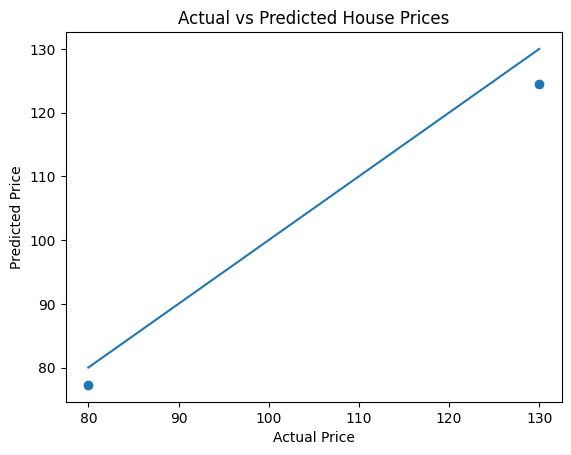

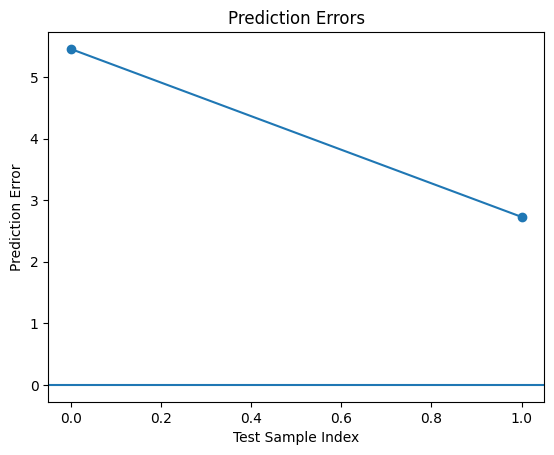


Predicted Price for new house: 99.54545454545453 lakhs


In [ ]:
# House Price Prediction with Evaluation + Graphs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# -----------------------------
# Step 1: Dataset
# -----------------------------
data = {
    'Area': [1000, 1500, 2000, 2500, 3000, 1200, 1800, 2200, 2700, 3200],
    'Rooms': [2, 3, 3, 4, 5, 2, 3, 3, 4, 5],
    'Floor': [1, 2, 2, 3, 3, 1, 2, 2, 3, 4],
    'Bathroom': [1, 2, 2, 3, 3, 1, 2, 2, 3, 4],
    'Location': ['A', 'B', 'A', 'B', 'C', 'A', 'B', 'C', 'B', 'C'],
    'Price': [50, 80, 90, 120, 150, 60, 85, 110, 130, 160]
}

df = pd.DataFrame(data)

# -----------------------------
# Step 2: Encoding categorical data
# -----------------------------
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

# -----------------------------
# Step 3: Features & Target
# -----------------------------
X = df.drop('Price', axis=1)
y = df['Price']

# -----------------------------
# Step 4: Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 5: Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Step 6: Model Training
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Step 7: Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Step 8: Evaluation Metrics
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

# -----------------------------
# Step 9: GRAPH 1 - Actual vs Predicted
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

# -----------------------------
# Step 10: GRAPH 2 - Error Plot
# -----------------------------
errors = y_test - y_pred

plt.figure()
plt.plot(range(len(errors)), errors, marker='o')
plt.axhline(y=0)
plt.xlabel("Test Sample Index")
plt.ylabel("Prediction Error")
plt.title("Prediction Errors")
plt.show()

# -----------------------------
# Step 11: Predict New House
# -----------------------------
new_house = pd.DataFrame({
    'Area': [2200],
    'Rooms': [3],
    'Floor': [2],
    'Bathroom': [2],
    'Location_B': [1],
    'Location_C': [0]
})

new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)

print("\nPredicted Price for new house:", predicted_price[0], "lakhs")

Nearest Neighbors: [(2.0, 'Red'), (2.23606797749979, 'Blue'), (2.23606797749979, 'Blue')]
Predicted Class for point (5,5): Blue


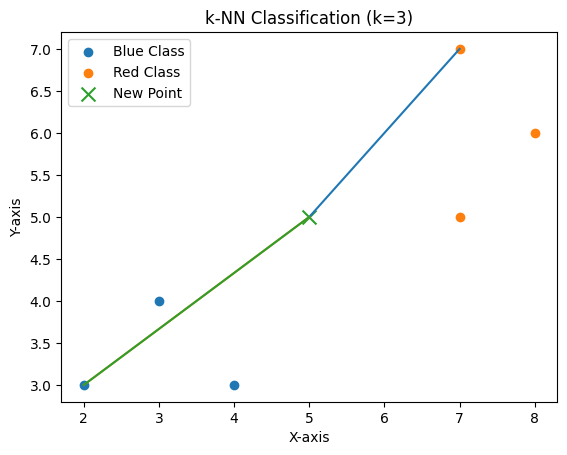

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Step 1: Dataset (same as paper activity)
blue_points = np.array([[2, 3], [3, 4], [4, 3]])
red_points = np.array([[7, 7], [8, 6], [7, 5]])

# Labels
blue_labels = ['Blue'] * len(blue_points)
red_labels = ['Red'] * len(red_points)

# Combine data
X = np.vstack((blue_points, red_points))
y = blue_labels + red_labels

# Step 2: New point
new_point = np.array([5, 5])

# Step 3: Choose k
k = 3

# Step 4: Calculate distances
distances = []
for i in range(len(X)):
    dist = sqrt((X[i][0] - new_point[0])**2 + (X[i][1] - new_point[1])**2)
    distances.append((dist, y[i]))

# Sort distances
distances.sort(key=lambda x: x[0])

# Step 5: Pick k nearest neighbors
neighbors = distances[:k]

# Voting
votes = [label for _, label in neighbors]
prediction = max(set(votes), key=votes.count)

print("Nearest Neighbors:", neighbors)
print("Predicted Class for point (5,5):", prediction)

# Step 6: Visualization
plt.scatter(blue_points[:,0], blue_points[:,1], label='Blue Class')
plt.scatter(red_points[:,0], red_points[:,1], label='Red Class')
plt.scatter(new_point[0], new_point[1], label='New Point', marker='x', s=100)

# Draw lines to neighbors
for dist, label in neighbors:
    idx = y.index(label)
    plt.plot([new_point[0], X[idx][0]], [new_point[1], X[idx][1]])

plt.legend()
plt.title("k-NN Classification (k=3)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()